In [7]:
import pandas as pd

# 读取 parquet
df_train = pd.read_parquet("df_trainsub_full_rl.parquet")
df_test  = pd.read_parquet("df_testsub_full_rl.parquet")

# 合并成一个 frame
df_full = pd.concat([df_train, df_test], axis=0, ignore_index=True)

# 排序（非常重要，RL / lag 都需要）
df_full = df_full.sort_values(
    ["SecuCode", "TradingDay", "TimeEnd"]
).reset_index(drop=True)

print("df_full shape:", df_full.shape)

df_full.head()

df_full shape: (1538980, 30)


,SecuCode,TradingDay,TimeStart,TimeEnd,mid,spread,microprice_minus_mid,Volume_sum,Turnover_sum,DealNum_sum,...,spread_over_mid,microprice_minus_mid_over_mid,log_volume_sum,log_volume_sum_cs_rank,ret_mid_t1_lag1,ret_mid_t1_lag2,signal_pre_boost,signal_pre_boost_cs_z,sig_mean_5,sig_std_5
0,400,20180105,1400,1415,12.545907,0.009359,-0.001625,666449.0,8929837.0,246.0,...,0.000746,-0.000130,13.409720,0.510638,0.000747,-0.002235,-0.000184,-0.000433,0.136814,0.301263
1,400,20180105,1415,1430,12.545907,0.009359,0.004534,649400.0,8709588.0,249.0,...,0.000746,0.000361,13.383806,0.446809,0.000000,0.000747,0.000286,0.876286,0.875732,0.133308
2,400,20180105,1430,1445,12.573985,0.009359,0.001348,766000.0,10288242.0,369.0,...,0.000744,0.000107,13.548939,0.382979,0.002238,0.000000,-0.000036,-0.033422,0.208418,0.347763
3,400,20180105,1445,1500,12.545907,0.009359,-0.003165,686098.0,9200730.0,274.0,...,0.000746,-0.000252,13.438777,0.404255,-0.002233,0.002238,-0.000376,-0.933310,-0.391072,0.697177
4,400,20180108,930,945,12.508471,0.009359,0.003633,858900.0,11482996.0,493.0,...,0.000748,0.000290,13.663409,0.234043,-0.002984,-0.002233,-0.000187,-0.530542,0.539987,0.624971


In [8]:
df_train.columns

Index(['SecuCode', 'TradingDay', 'TimeStart', 'TimeEnd', 'mid', 'spread',
       'microprice_minus_mid', 'Volume_sum', 'Turnover_sum', 'DealNum_sum',
       'VWAP', 'ret_mid_t1', 'signal_hybrid', 'signal_ssm_tf',
       'signal_tf_cross', 'signal_gat_tf', 'signal_hybrid_cs_z',
       'signal_ssm_tf_cs_z', 'signal_tf_cross_cs_z', 'signal_gat_tf_cs_z',
       'spread_over_mid', 'microprice_minus_mid_over_mid', 'log_volume_sum',
       'log_volume_sum_cs_rank', 'ret_mid_t1_lag1', 'ret_mid_t1_lag2',
       'signal_pre_boost', 'signal_pre_boost_cs_z', 'sig_mean_5', 'sig_std_5'],
      dtype='object')

In [21]:
# =========================================================
# Multi-Agent DDPG with Shared Critic + A-share T+1 execution
# All-in-one single frame version
#
# Updated as requested:
# - NO risk penalty
# - NO fees
# - ONLY spread cost
# - everything kept in one frame
# =========================================================

import os
import copy
import json
import random
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm

torch.set_float32_matmul_precision("high")


# =========================================================
# 0) Seed / Device
# =========================================================
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)


# =========================================================
# 1) Config
# =========================================================
@dataclass
class CFG:
    # ---------- basic columns ----------
    stock_col: str = "SecuCode"
    day_col: str = "TradingDay"
    time_col: str = "TimeEnd"
    price_col: str = "mid"
    spread_col: str = "spread"
    ret_col: str = "ret_mid_t1"

    # ---------- agents ----------
    agent_signal_cols = (
        "signal_pre_boost_cs_z",
        "signal_hybrid_cs_z",
        "signal_ssm_tf_cs_z",
        "signal_tf_cross_cs_z",
        "signal_gat_tf_cs_z",
    )

    # ---------- shared state features ----------
    shared_state_cols = (
        "sig_mean_5",
        "sig_std_5",
        "spread_over_mid",
        "microprice_minus_mid_over_mid",
        "log_volume_sum_cs_rank",
        "ret_mid_t1_lag1",
        "ret_mid_t1_lag2",
    )

    # ---------- fee / cost ----------
    # ALL FEES OFF
    broker_commission_rate: float = 0.0
    exchange_reg_transfer_rate: float = 0.0
    sell_stamp_duty_rate: float = 0.0
    use_half_spread: bool = True

    # ---------- portfolio ----------
    long_only: bool = True
    topk: int | None = None
    max_weight_per_stock: float = 0.20

    # ---------- reward ----------
    # NO risk penalty, NO turnover penalty
    risk_penalty_lambda: float = 0.0
    turnover_penalty_lambda: float = 0.0

    # ---------- RL ----------
    hidden_dim: int = 128
    actor_lr: float = 1e-4
    critic_lr: float = 3e-4
    gamma: float = 0.99
    tau: float = 0.005

    replay_capacity: int = 300000
    batch_size: int = 512
    warmup_steps: int = 2000
    epochs: int = 15
    action_noise_std: float = 0.10
    train_every: int = 2
    updates_per_step: int = 2

    # ---------- save ----------
    save_dir: str = "maddpg_sharedcritic_models_spread_only"


cfg = CFG()

agent_cols = list(cfg.agent_signal_cols)
shared_cols = list(cfg.shared_state_cols)
n_agents = len(agent_cols)
state_dim = 2 * (1 + len(shared_cols))
action_dim = 1


# =========================================================
# 2) Data preparation
# =========================================================
def prepare_dataframe(df_raw: pd.DataFrame, cfg: CFG, show_progress: bool = True):
    pbar = tqdm(total=6, desc="Prepare dataframe", leave=False, disable=not show_progress)

    need_cols = [
        cfg.stock_col, cfg.day_col, cfg.time_col,
        cfg.price_col, cfg.spread_col, cfg.ret_col,
        *cfg.agent_signal_cols,
        *cfg.shared_state_cols,
    ]
    missing = [c for c in need_cols if c not in df_raw.columns]
    if missing:
        raise ValueError(f"Missing columns in input dataframe: {missing}")

    df = df_raw[need_cols].copy()
    df = df.replace([np.inf, -np.inf], np.nan)
    pbar.update(1)
    pbar.set_postfix_str(f"rows={len(df):,}")

    # sort by stock-time for filling
    df = df.sort_values([cfg.stock_col, cfg.day_col, cfg.time_col]).reset_index(drop=True)
    pbar.update(1)

    fill_cols = list(cfg.agent_signal_cols) + list(cfg.shared_state_cols)
    df[fill_cols] = df.groupby(cfg.stock_col, sort=False)[fill_cols].ffill()
    df[fill_cols] = df.groupby(cfg.stock_col, sort=False)[fill_cols].bfill()
    df[fill_cols] = df[fill_cols].fillna(0.0)
    pbar.update(1)

    df[cfg.spread_col] = df[cfg.spread_col].fillna(0.0).clip(lower=0.0)
    df[cfg.price_col] = df[cfg.price_col].replace(0, np.nan)
    df[cfg.price_col] = df.groupby(cfg.stock_col, sort=False)[cfg.price_col].ffill()
    df[cfg.price_col] = df.groupby(cfg.stock_col, sort=False)[cfg.price_col].bfill()
    df[cfg.price_col] = df[cfg.price_col].fillna(1.0)
    df[cfg.ret_col] = df[cfg.ret_col].fillna(0.0)
    pbar.update(1)

    # sort for training order
    df = df.sort_values([cfg.day_col, cfg.time_col, cfg.stock_col]).reset_index(drop=True)
    pbar.update(1)

    # build ts index and snapshots
    df["ts_key"] = list(zip(df[cfg.day_col].values, df[cfg.time_col].values))
    unique_ts = df["ts_key"].drop_duplicates().tolist()
    ts_to_idx = {k: i for i, k in enumerate(unique_ts)}
    df["ts_idx"] = df["ts_key"].map(ts_to_idx).astype(int)

    snapshots = []
    ts_group_iter = df.groupby("ts_idx", sort=True)
    if show_progress:
        ts_group_iter = tqdm(ts_group_iter, total=df["ts_idx"].nunique(), desc="Build snapshots", leave=False)

    for _, sub in ts_group_iter:
        sub = sub.sort_values(cfg.stock_col).reset_index(drop=False)
        snapshots.append(sub)

    pbar.update(1)
    pbar.close()
    return df, snapshots


def build_snapshot_cache(df: pd.DataFrame, snapshots, cfg: CFG, show_progress: bool = True):
    cache = []
    iterator = snapshots
    if show_progress:
        iterator = tqdm(snapshots, total=len(snapshots), desc="Cache snapshots", leave=False)

    for sub in iterator:
        d = {}
        d["row_idx"] = sub["index"].values.astype(np.int64)
        d["codes"] = sub[cfg.stock_col].values
        d["n_stock"] = len(sub)
        d["day"] = sub[cfg.day_col].iloc[0]

        d["mid"] = sub[cfg.price_col].values.astype(np.float32)
        d["spread"] = sub[cfg.spread_col].values.astype(np.float32)
        d["ret_next"] = sub[cfg.ret_col].values.astype(np.float32)

        # NO risk penalty -> sigma proxy is zero
        d["sigma_proxy"] = np.zeros(len(sub), dtype=np.float32)

        d["agent_signal_mat"] = np.stack(
            [sub[c].values.astype(np.float32) for c in agent_cols],
            axis=1
        )  # [N, A]

        shared_mat = np.stack(
            [sub[c].values.astype(np.float32) for c in shared_cols],
            axis=1
        )  # [N, S_shared]
        d["shared_mat"] = shared_mat

        states = []
        for i in range(len(agent_cols)):
            own_sig = d["agent_signal_mat"][:, i:i+1]
            x = np.concatenate([own_sig, shared_mat], axis=1)
            mean_feat = np.nanmean(x, axis=0)
            std_feat = np.nanstd(x, axis=0)
            state = np.concatenate([mean_feat, std_feat], axis=0)
            state = np.nan_to_num(state, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
            states.append(state)

        d["states"] = np.stack(states, axis=0)  # [A, state_dim]
        cache.append(d)

    return cache


# =========================================================
# 3) Portfolio / execution / reward helpers
# =========================================================
def build_portfolio_weights_from_agent_scores(
    agent_scores: np.ndarray,
    prev_w: np.ndarray,
    long_only: bool = True,
    max_weight_per_stock: float = 0.20,
    topk: int | None = None,
):
    final_score = agent_scores.mean(axis=1).astype(np.float32)

    if topk is not None and topk < len(final_score):
        idx = np.argpartition(final_score, -topk)[-topk:]
        mask = np.zeros(len(final_score), dtype=bool)
        mask[idx] = True
        score = np.where(mask, final_score, -1e9 if long_only else 0.0)
    else:
        score = final_score

    if long_only:
        raw = np.maximum(score, 0.0).astype(np.float32)
        s = raw.sum()
        if s <= 1e-12:
            w = np.zeros_like(raw, dtype=np.float32)
        else:
            w = (raw / s).astype(np.float32)
    else:
        pos = np.maximum(score, 0.0).astype(np.float32)
        neg = np.maximum(-score, 0.0).astype(np.float32)
        if pos.sum() > 1e-12:
            pos = pos / pos.sum()
        if neg.sum() > 1e-12:
            neg = neg / neg.sum()
        w = (pos - neg).astype(np.float32)

    if long_only:
        w = np.clip(w, 0.0, max_weight_per_stock).astype(np.float32)
        s = w.sum()
        if s > 1e-12:
            w = (w / s).astype(np.float32)

    delta_w = (w - prev_w).astype(np.float32)
    buy_w = np.maximum(delta_w, 0.0).astype(np.float32)
    sell_w = np.maximum(-delta_w, 0.0).astype(np.float32)

    return final_score, w, buy_w, sell_w


def refresh_sellable_on_new_day(
    prev_day,
    cur_day,
    inventory_w: np.ndarray,
    sellable_w: np.ndarray,
):
    if prev_day is None:
        return np.asarray(sellable_w, dtype=np.float32)
    if cur_day != prev_day:
        return np.asarray(inventory_w, dtype=np.float32).copy()
    return np.asarray(sellable_w, dtype=np.float32)


def execute_target_weight_t1(
    target_w: np.ndarray,
    inventory_w: np.ndarray,
    sellable_w: np.ndarray,
    max_weight_per_stock: float = 0.20,
    long_only: bool = True,
):
    """
    Execute target weights under A-share T+1 sell constraint.
    """
    target_w = np.asarray(target_w, dtype=np.float32)
    inventory_w = np.asarray(inventory_w, dtype=np.float32)
    sellable_w = np.asarray(sellable_w, dtype=np.float32)

    if long_only:
        target_w = np.maximum(target_w, 0.0).astype(np.float32)

    target_w = np.clip(target_w, 0.0, max_weight_per_stock).astype(np.float32)

    s = target_w.sum()
    if s > 1e-12:
        target_w = (target_w / s).astype(np.float32)

    desired_sell = np.maximum(inventory_w - target_w, 0.0).astype(np.float32)
    desired_buy = np.maximum(target_w - inventory_w, 0.0).astype(np.float32)

    # T+1 restriction
    sell_w = np.minimum(desired_sell, sellable_w).astype(np.float32)

    inventory_after_sell = (inventory_w - sell_w).astype(np.float32)
    sellable_after_sell = (sellable_w - sell_w).astype(np.float32)

    cash_before = max(0.0, 1.0 - float(inventory_w.sum()))
    cash_from_sell = float(sell_w.sum())
    cash_available = cash_before + cash_from_sell

    desired_buy_sum = float(desired_buy.sum())
    if desired_buy_sum <= 1e-12 or cash_available <= 1e-12:
        buy_w = np.zeros_like(desired_buy, dtype=np.float32)
    else:
        buy_scale = min(1.0, cash_available / desired_buy_sum)
        buy_w = (desired_buy * buy_scale).astype(np.float32)

    inventory_w_new = (inventory_after_sell + buy_w).astype(np.float32)

    # newly bought amount is not sellable on same day
    sellable_w_new_same_day = sellable_after_sell.astype(np.float32)

    exec_w = inventory_w_new.astype(np.float32)

    exec_w = np.clip(exec_w, 0.0, max_weight_per_stock).astype(np.float32)
    total_exec = float(exec_w.sum())
    if total_exec > 1.000001:
        exec_w = (exec_w / total_exec).astype(np.float32)
        inventory_w_new = exec_w.copy()
        sellable_w_new_same_day = np.minimum(sellable_w_new_same_day, inventory_w_new).astype(np.float32)
        delta = (inventory_w_new - inventory_w).astype(np.float32)
        buy_w = np.maximum(delta, 0.0).astype(np.float32)
        sell_w = np.maximum(-delta, 0.0).astype(np.float32)

    cash_left = max(0.0, 1.0 - float(exec_w.sum()))
    return exec_w, buy_w, sell_w, inventory_w_new, sellable_w_new_same_day, cash_left


def calc_reward_from_cache(
    mid: np.ndarray,
    spread: np.ndarray,
    ret_next: np.ndarray,
    sigma_proxy: np.ndarray,
    new_w: np.ndarray,
    prev_w: np.ndarray,
    cfg: CFG,
):
    """
    Spread-only reward:
        reward = gross_return - spread_cost
    No fees, no risk penalty, no turnover penalty.
    """
    delta_w = (new_w - prev_w).astype(np.float32)
    buy_w = np.maximum(delta_w, 0.0).astype(np.float32)
    sell_w = np.maximum(-delta_w, 0.0).astype(np.float32)

    spread_frac = np.divide(
        spread,
        np.maximum(mid, 1e-8),
        out=np.zeros_like(spread, dtype=np.float32),
        where=np.maximum(mid, 1e-8) > 0
    ).astype(np.float32)

    half_mult = 0.5 if cfg.use_half_spread else 1.0
    spread_cost_each = (buy_w + sell_w) * half_mult * spread_frac

    gross_return = float(np.dot(new_w, ret_next))
    spread_cost = float(spread_cost_each.sum())

    buy_fee = 0.0
    sell_fee = 0.0
    risk_penalty = 0.0

    turnover = float(np.abs(delta_w).sum())
    turnover_penalty = 0.0

    reward = gross_return - spread_cost

    info = {
        "gross_return": gross_return,
        "spread_cost": spread_cost,
        "buy_fee": buy_fee,
        "sell_fee": sell_fee,
        "risk_penalty": risk_penalty,
        "turnover_penalty": turnover_penalty,
        "turnover": turnover,
        "reward": reward,
    }
    return reward, info


# =========================================================
# 4) Replay Buffer
# =========================================================
class ReplayBuffer:
    def __init__(self, capacity, n_agents, state_dim, action_dim):
        self.capacity = capacity
        self.n_agents = n_agents
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.buffer = []
        self.pos = 0

    def push(self, states, actions, reward, next_states, done):
        item = (
            np.asarray(states, dtype=np.float32),
            np.asarray(actions, dtype=np.float32),
            np.float32(reward),
            np.asarray(next_states, dtype=np.float32),
            np.float32(done),
        )
        if len(self.buffer) < self.capacity:
            self.buffer.append(item)
        else:
            self.buffer[self.pos] = item
        self.pos = (self.pos + 1) % self.capacity

    def sample(self, batch_size):
        idx = np.random.choice(len(self.buffer), batch_size, replace=False)
        batch = [self.buffer[i] for i in idx]
        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.tensor(np.stack(states), dtype=torch.float32, device=DEVICE)
        actions = torch.tensor(np.stack(actions), dtype=torch.float32, device=DEVICE)
        rewards = torch.tensor(np.array(rewards), dtype=torch.float32, device=DEVICE).unsqueeze(-1)
        next_states = torch.tensor(np.stack(next_states), dtype=torch.float32, device=DEVICE)
        dones = torch.tensor(np.array(dones), dtype=torch.float32, device=DEVICE).unsqueeze(-1)
        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)


# =========================================================
# 5) Networks
# =========================================================
class Actor(nn.Module):
    def __init__(self, state_dim, hidden_dim=128, action_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
            nn.Tanh(),
        )

    def forward(self, x):
        return self.net(x)


class SharedCritic(nn.Module):
    def __init__(self, n_agents, state_dim, action_dim, hidden_dim=128):
        super().__init__()
        in_dim = n_agents * state_dim + n_agents * action_dim
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, states, actions):
        x = torch.cat(
            [
                states.reshape(states.size(0), -1),
                actions.reshape(actions.size(0), -1),
            ],
            dim=1,
        )
        return self.net(x)


# =========================================================
# 6) MADDPG with non-shared actors + shared critic
# =========================================================
class MADDPGSharedCritic:
    def __init__(self, n_agents, state_dim, action_dim, cfg: CFG):
        self.n_agents = n_agents
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.cfg = cfg

        self.actors = [
            Actor(state_dim, cfg.hidden_dim, action_dim).to(DEVICE)
            for _ in range(n_agents)
        ]
        self.target_actors = [
            copy.deepcopy(actor).to(DEVICE)
            for actor in self.actors
        ]

        self.critic = SharedCritic(n_agents, state_dim, action_dim, cfg.hidden_dim).to(DEVICE)
        self.target_critic = copy.deepcopy(self.critic).to(DEVICE)

        self.actor_opts = [
            torch.optim.Adam(actor.parameters(), lr=cfg.actor_lr)
            for actor in self.actors
        ]
        self.critic_opt = torch.optim.Adam(self.critic.parameters(), lr=cfg.critic_lr)

    @torch.no_grad()
    def act(self, states_np, noise_std=0.0):
        actions = []
        for i in range(self.n_agents):
            s = torch.tensor(states_np[i], dtype=torch.float32, device=DEVICE).unsqueeze(0)
            a = self.actors[i](s).squeeze(0).cpu().numpy()
            if noise_std > 0:
                a = a + np.random.normal(0.0, noise_std, size=a.shape)
            a = np.clip(a, -1.0, 1.0).astype(np.float32)
            actions.append(a)
        return np.stack(actions, axis=0)

    def soft_update(self, online_net, target_net):
        for p, tp in zip(online_net.parameters(), target_net.parameters()):
            tp.data.copy_(self.cfg.tau * p.data + (1.0 - self.cfg.tau) * tp.data)

    def update(self, replay: ReplayBuffer, batch_size=256):
        if len(replay) < batch_size:
            return {}

        states, actions, rewards, next_states, dones = replay.sample(batch_size)

        with torch.no_grad():
            next_actions = []
            for i in range(self.n_agents):
                ai_next = self.target_actors[i](next_states[:, i, :])
                next_actions.append(ai_next)
            next_actions = torch.stack(next_actions, dim=1)

            target_q = self.target_critic(next_states, next_actions)
            y = rewards + self.cfg.gamma * (1.0 - dones) * target_q

        q = self.critic(states, actions)
        critic_loss = F.mse_loss(q, y)

        self.critic_opt.zero_grad(set_to_none=True)
        critic_loss.backward()
        nn.utils.clip_grad_norm_(self.critic.parameters(), 1.0)
        self.critic_opt.step()

        actor_losses = []
        for i in range(self.n_agents):
            curr_actions = actions.clone()
            curr_actions[:, i, :] = self.actors[i](states[:, i, :])
            actor_loss = -self.critic(states, curr_actions).mean()

            self.actor_opts[i].zero_grad(set_to_none=True)
            actor_loss.backward()
            nn.utils.clip_grad_norm_(self.actors[i].parameters(), 1.0)
            self.actor_opts[i].step()

            actor_losses.append(float(actor_loss.item()))

        for i in range(self.n_agents):
            self.soft_update(self.actors[i], self.target_actors[i])
        self.soft_update(self.critic, self.target_critic)

        logs = {"critic_loss": float(critic_loss.item())}
        for i, loss_val in enumerate(actor_losses):
            logs[f"actor_loss_{i}"] = loss_val
        return logs


# =========================================================
# 7) Save / Load
# =========================================================
def save_maddpg_model(model: MADDPGSharedCritic, cfg: CFG, save_dir=None):
    if save_dir is None:
        save_dir = cfg.save_dir

    os.makedirs(save_dir, exist_ok=True)

    with open(os.path.join(save_dir, "config.json"), "w", encoding="utf-8") as f:
        json.dump(asdict(cfg), f, ensure_ascii=False, indent=2)

    for i, actor in enumerate(model.actors):
        torch.save(actor.state_dict(), os.path.join(save_dir, f"actor_agent_{i}.pt"))

    for i, target_actor in enumerate(model.target_actors):
        torch.save(target_actor.state_dict(), os.path.join(save_dir, f"target_actor_agent_{i}.pt"))

    torch.save(model.critic.state_dict(), os.path.join(save_dir, "shared_critic.pt"))
    torch.save(model.target_critic.state_dict(), os.path.join(save_dir, "target_shared_critic.pt"))

    print(f"Model saved to: {save_dir}")


def load_maddpg_model(cfg: CFG, n_agents: int, state_dim: int, action_dim: int, save_dir=None):
    if save_dir is None:
        save_dir = cfg.save_dir

    model = MADDPGSharedCritic(
        n_agents=n_agents,
        state_dim=state_dim,
        action_dim=action_dim,
        cfg=cfg,
    )

    for i in range(n_agents):
        actor_path = os.path.join(save_dir, f"actor_agent_{i}.pt")
        model.actors[i].load_state_dict(torch.load(actor_path, map_location=DEVICE))

        target_actor_path = os.path.join(save_dir, f"target_actor_agent_{i}.pt")
        if os.path.exists(target_actor_path):
            model.target_actors[i].load_state_dict(torch.load(target_actor_path, map_location=DEVICE))
        else:
            model.target_actors[i].load_state_dict(torch.load(actor_path, map_location=DEVICE))

    critic_path = os.path.join(save_dir, "shared_critic.pt")
    model.critic.load_state_dict(torch.load(critic_path, map_location=DEVICE))

    target_critic_path = os.path.join(save_dir, "target_shared_critic.pt")
    if os.path.exists(target_critic_path):
        model.target_critic.load_state_dict(torch.load(target_critic_path, map_location=DEVICE))
    else:
        model.target_critic.load_state_dict(torch.load(critic_path, map_location=DEVICE))

    print(f"Model loaded from: {save_dir}")
    return model


# =========================================================
# 8) Train
# =========================================================
def train_maddpg_on_frame(df_train: pd.DataFrame, cfg: CFG):
    print("Step 1/3: prepare_dataframe ...")
    df, snapshots = prepare_dataframe(df_train, cfg, show_progress=True)
    print(f"Done prepare_dataframe. rows={len(df):,}, timestamps={len(snapshots):,}")

    if len(snapshots) < 2:
        raise ValueError("Need at least 2 timestamps to train.")

    print("Step 2/3: build_snapshot_cache ...")
    cache = build_snapshot_cache(df, snapshots, cfg, show_progress=True)
    print(f"Done build_snapshot_cache. cached timestamps={len(cache):,}")

    print("Step 3/3: start training ...")

    replay = ReplayBuffer(cfg.replay_capacity, n_agents, state_dim, action_dim)
    model = MADDPGSharedCritic(n_agents, state_dim, action_dim, cfg)

    n_rows = len(df)
    final_score_buf = np.full(n_rows, np.nan, dtype=np.float32)
    target_weight_buf = np.full(n_rows, np.nan, dtype=np.float32)
    final_weight_buf = np.full(n_rows, np.nan, dtype=np.float32)
    sellable_weight_buf = np.full(n_rows, np.nan, dtype=np.float32)
    reward_buf = np.full(n_rows, np.nan, dtype=np.float32)
    gross_return_buf = np.full(n_rows, np.nan, dtype=np.float32)
    spread_cost_buf = np.full(n_rows, np.nan, dtype=np.float32)
    buy_fee_buf = np.full(n_rows, np.nan, dtype=np.float32)
    sell_fee_buf = np.full(n_rows, np.nan, dtype=np.float32)
    risk_penalty_buf = np.full(n_rows, np.nan, dtype=np.float32)
    turnover_buf = np.full(n_rows, np.nan, dtype=np.float32)

    agent_raw_bufs = {
        c: np.full(n_rows, np.nan, dtype=np.float32)
        for c in agent_cols
    }

    history = []
    global_step = 0
    best_mean_reward = -np.inf

    epoch_pbar = tqdm(range(cfg.epochs), desc="Training Epoch", position=0)

    for epoch in epoch_pbar:
        epoch_rewards = []
        last_logs = {}

        inventory_map = {}
        sellable_map = {}
        prev_day = None

        ts_pbar = tqdm(
            range(len(cache) - 1),
            desc=f"Epoch {epoch+1}/{cfg.epochs}",
            position=1,
            leave=False
        )

        for t in ts_pbar:
            cur = cache[t]
            nxt = cache[t + 1]
            cur_day = cur["day"]
            cur_codes = cur["codes"]

            inventory_w = np.fromiter(
                (inventory_map.get(code, 0.0) for code in cur_codes),
                dtype=np.float32,
                count=cur["n_stock"]
            )
            sellable_w = np.fromiter(
                (sellable_map.get(code, 0.0) for code in cur_codes),
                dtype=np.float32,
                count=cur["n_stock"]
            )

            sellable_w = refresh_sellable_on_new_day(
                prev_day=prev_day,
                cur_day=cur_day,
                inventory_w=inventory_w,
                sellable_w=sellable_w,
            )

            states = cur["states"]
            next_states = nxt["states"]

            noise_std = cfg.action_noise_std if epoch > 0 else max(cfg.action_noise_std, 0.15)
            actions = model.act(states, noise_std=noise_std)

            gates = actions.reshape(1, -1)
            agent_scores = (cur["agent_signal_mat"] * gates).astype(np.float32)

            final_score, target_w, _, _ = build_portfolio_weights_from_agent_scores(
                agent_scores=agent_scores,
                prev_w=inventory_w,
                long_only=cfg.long_only,
                max_weight_per_stock=cfg.max_weight_per_stock,
                topk=cfg.topk,
            )

            exec_w, buy_w, sell_w, inventory_w_new, sellable_w_new_same_day, cash_left = execute_target_weight_t1(
                target_w=target_w,
                inventory_w=inventory_w,
                sellable_w=sellable_w,
                max_weight_per_stock=cfg.max_weight_per_stock,
                long_only=cfg.long_only,
            )

            reward, info = calc_reward_from_cache(
                mid=cur["mid"],
                spread=cur["spread"],
                ret_next=cur["ret_next"],
                sigma_proxy=cur["sigma_proxy"],
                new_w=exec_w,
                prev_w=inventory_w,
                cfg=cfg,
            )

            done = 1.0 if (t == len(cache) - 2) else 0.0
            replay.push(states, actions, reward, next_states, done)

            if len(replay) >= max(cfg.batch_size, cfg.warmup_steps) and global_step % cfg.train_every == 0:
                for _ in range(cfg.updates_per_step):
                    last_logs = model.update(replay, cfg.batch_size)

            row_idx = cur["row_idx"]
            final_score_buf[row_idx] = final_score
            target_weight_buf[row_idx] = target_w
            final_weight_buf[row_idx] = exec_w
            sellable_weight_buf[row_idx] = sellable_w
            reward_buf[row_idx] = info["reward"]
            gross_return_buf[row_idx] = info["gross_return"]
            spread_cost_buf[row_idx] = info["spread_cost"]
            buy_fee_buf[row_idx] = info["buy_fee"]
            sell_fee_buf[row_idx] = info["sell_fee"]
            risk_penalty_buf[row_idx] = info["risk_penalty"]
            turnover_buf[row_idx] = info["turnover"]

            for i, c in enumerate(agent_cols):
                agent_raw_bufs[c][row_idx] = agent_scores[:, i]

            inventory_map = {code: float(w) for code, w in zip(cur_codes, inventory_w_new)}
            sellable_map = {code: float(w) for code, w in zip(cur_codes, sellable_w_new_same_day)}
            prev_day = cur_day

            epoch_rewards.append(reward)
            global_step += 1

            ts_pbar.set_postfix({
                "reward": f"{reward:.6f}",
                "turnover": f"{info['turnover']:.4f}",
                "sellable": f"{sellable_w.sum():.4f}",
                "buffer": len(replay),
                "critic": f"{last_logs.get('critic_loss', np.nan):.4f}" if last_logs else "nan",
            })

        mean_reward = float(np.mean(epoch_rewards)) if len(epoch_rewards) > 0 else np.nan

        rec = {"epoch": epoch, "mean_reward": mean_reward}
        rec.update(last_logs)
        history.append(rec)

        epoch_pbar.set_postfix({
            "mean_reward": f"{mean_reward:.6f}",
            "best": f"{max(best_mean_reward, mean_reward):.6f}"
        })

        print(f"[Epoch {epoch+1}/{cfg.epochs}] mean_reward={mean_reward:.8f}")

        if mean_reward > best_mean_reward:
            best_mean_reward = mean_reward
            save_maddpg_model(model, cfg, cfg.save_dir)

    df_out = df.copy()
    df_out["final_score"] = final_score_buf
    df_out["target_weight"] = target_weight_buf
    df_out["final_weight"] = final_weight_buf
    df_out["sellable_weight"] = sellable_weight_buf
    df_out["reward_ts"] = reward_buf
    df_out["gross_return_ts"] = gross_return_buf
    df_out["spread_cost_ts"] = spread_cost_buf
    df_out["buy_fee_ts"] = buy_fee_buf
    df_out["sell_fee_ts"] = sell_fee_buf
    df_out["risk_penalty_ts"] = risk_penalty_buf
    df_out["turnover_ts"] = turnover_buf

    for c in agent_cols:
        df_out[f"agent_raw_{c}"] = agent_raw_bufs[c]

    hist_df = pd.DataFrame(history)
    return model, df_out, hist_df


# =========================================================
# 9) Predict
# =========================================================
@torch.no_grad()
def predict_maddpg_weights(df_input: pd.DataFrame, model: MADDPGSharedCritic, cfg: CFG):
    print("Step 1/2: prepare_dataframe ...")
    df, snapshots = prepare_dataframe(df_input, cfg, show_progress=True)
    print(f"Done prepare_dataframe. rows={len(df):,}, timestamps={len(snapshots):,}")

    print("Step 2/2: build_snapshot_cache ...")
    cache = build_snapshot_cache(df, snapshots, cfg, show_progress=True)
    print(f"Done build_snapshot_cache. cached timestamps={len(cache):,}")

    n_rows = len(df)
    final_score_buf = np.full(n_rows, np.nan, dtype=np.float32)
    target_weight_buf = np.full(n_rows, np.nan, dtype=np.float32)
    final_weight_buf = np.full(n_rows, np.nan, dtype=np.float32)
    sellable_weight_buf = np.full(n_rows, np.nan, dtype=np.float32)
    reward_buf = np.full(n_rows, np.nan, dtype=np.float32)
    gross_return_buf = np.full(n_rows, np.nan, dtype=np.float32)
    spread_cost_buf = np.full(n_rows, np.nan, dtype=np.float32)
    buy_fee_buf = np.full(n_rows, np.nan, dtype=np.float32)
    sell_fee_buf = np.full(n_rows, np.nan, dtype=np.float32)
    risk_penalty_buf = np.full(n_rows, np.nan, dtype=np.float32)
    turnover_buf = np.full(n_rows, np.nan, dtype=np.float32)

    agent_raw_bufs = {
        c: np.full(n_rows, np.nan, dtype=np.float32)
        for c in agent_cols
    }

    inventory_map = {}
    sellable_map = {}
    prev_day = None

    ts_pbar = tqdm(range(len(cache)), desc="Predict timestamps")

    for t in ts_pbar:
        cur = cache[t]
        cur_day = cur["day"]
        cur_codes = cur["codes"]

        inventory_w = np.fromiter(
            (inventory_map.get(code, 0.0) for code in cur_codes),
            dtype=np.float32,
            count=cur["n_stock"]
        )
        sellable_w = np.fromiter(
            (sellable_map.get(code, 0.0) for code in cur_codes),
            dtype=np.float32,
            count=cur["n_stock"]
        )

        sellable_w = refresh_sellable_on_new_day(
            prev_day=prev_day,
            cur_day=cur_day,
            inventory_w=inventory_w,
            sellable_w=sellable_w,
        )

        states = cur["states"]
        actions = model.act(states, noise_std=0.0)

        gates = actions.reshape(1, -1)
        agent_scores = (cur["agent_signal_mat"] * gates).astype(np.float32)

        final_score, target_w, _, _ = build_portfolio_weights_from_agent_scores(
            agent_scores=agent_scores,
            prev_w=inventory_w,
            long_only=cfg.long_only,
            max_weight_per_stock=cfg.max_weight_per_stock,
            topk=cfg.topk,
        )

        exec_w, buy_w, sell_w, inventory_w_new, sellable_w_new_same_day, cash_left = execute_target_weight_t1(
            target_w=target_w,
            inventory_w=inventory_w,
            sellable_w=sellable_w,
            max_weight_per_stock=cfg.max_weight_per_stock,
            long_only=cfg.long_only,
        )

        reward, info = calc_reward_from_cache(
            mid=cur["mid"],
            spread=cur["spread"],
            ret_next=cur["ret_next"],
            sigma_proxy=cur["sigma_proxy"],
            new_w=exec_w,
            prev_w=inventory_w,
            cfg=cfg,
        )

        row_idx = cur["row_idx"]
        final_score_buf[row_idx] = final_score
        target_weight_buf[row_idx] = target_w
        final_weight_buf[row_idx] = exec_w
        sellable_weight_buf[row_idx] = sellable_w
        reward_buf[row_idx] = info["reward"]
        gross_return_buf[row_idx] = info["gross_return"]
        spread_cost_buf[row_idx] = info["spread_cost"]
        buy_fee_buf[row_idx] = info["buy_fee"]
        sell_fee_buf[row_idx] = info["sell_fee"]
        risk_penalty_buf[row_idx] = info["risk_penalty"]
        turnover_buf[row_idx] = info["turnover"]

        for i, c in enumerate(agent_cols):
            agent_raw_bufs[c][row_idx] = agent_scores[:, i]

        inventory_map = {code: float(w) for code, w in zip(cur_codes, inventory_w_new)}
        sellable_map = {code: float(w) for code, w in zip(cur_codes, sellable_w_new_same_day)}
        prev_day = cur_day

        ts_pbar.set_postfix({
            "reward": f"{info['reward']:.6f}",
            "turnover": f"{info['turnover']:.4f}",
            "sellable": f"{sellable_w.sum():.4f}",
        })

    df_pred = df.copy()
    df_pred["final_score"] = final_score_buf
    df_pred["target_weight"] = target_weight_buf
    df_pred["final_weight"] = final_weight_buf
    df_pred["sellable_weight"] = sellable_weight_buf
    df_pred["reward_ts"] = reward_buf
    df_pred["gross_return_ts"] = gross_return_buf
    df_pred["spread_cost_ts"] = spread_cost_buf
    df_pred["buy_fee_ts"] = buy_fee_buf
    df_pred["sell_fee_ts"] = sell_fee_buf
    df_pred["risk_penalty_ts"] = risk_penalty_buf
    df_pred["turnover_ts"] = turnover_buf

    for c in agent_cols:
        df_pred[f"agent_raw_{c}"] = agent_raw_bufs[c]

    return df_pred


# =========================================================
# 10) Backtest helper
# =========================================================
def backtest_from_weight_frame(
    df_weight: pd.DataFrame,
    cfg: CFG,
    weight_col: str = "final_weight",
):
    """
    Gross-only portfolio timeseries based on already executed weights.
    """
    need_cols = [
        cfg.day_col, cfg.time_col, cfg.stock_col,
        weight_col, cfg.ret_col, cfg.price_col, cfg.spread_col
    ]
    x = df_weight[need_cols].copy().sort_values([cfg.day_col, cfg.time_col, cfg.stock_col]).reset_index(drop=True)

    records = []
    for (d, t), sub in tqdm(x.groupby([cfg.day_col, cfg.time_col], sort=True), desc="Backtest timestamps"):
        w = sub[weight_col].values.astype(np.float32)
        ret_next = sub[cfg.ret_col].values.astype(np.float32)

        gross_return = float(np.dot(w, ret_next))

        records.append({
            cfg.day_col: d,
            cfg.time_col: t,
            "gross_return": gross_return,
        })

    bt = pd.DataFrame(records)
    if len(bt):
        bt["nav"] = (1.0 + bt["gross_return"].fillna(0.0)).cumprod()
    return bt


# =========================================================
# 11) Build NAV from prediction output
# =========================================================
def build_nav_from_pred(df_pred: pd.DataFrame, cfg: CFG):
    need_cols = [
        cfg.day_col,
        cfg.time_col,
        "gross_return_ts",
        "spread_cost_ts",
        "reward_ts",
        "turnover_ts",
    ]
    x = df_pred[need_cols].copy()

    ts_curve = (
        x.sort_values([cfg.day_col, cfg.time_col])
         .groupby([cfg.day_col, cfg.time_col], as_index=False)
         .first()
         .copy()
    )

    ts_curve["net_return_ts"] = (
        ts_curve["gross_return_ts"].fillna(0.0)
        - ts_curve["spread_cost_ts"].fillna(0.0)
    )

    ts_curve["gross_nav"] = (1.0 + ts_curve["gross_return_ts"].fillna(0.0)).cumprod()
    ts_curve["net_nav"] = (1.0 + ts_curve["net_return_ts"].fillna(0.0)).cumprod()
    ts_curve["reward_nav"] = (1.0 + ts_curve["reward_ts"].fillna(0.0)).cumprod()
    return ts_curve




DEVICE: cuda


In [ ]:

model, df_train_out, hist_df = train_maddpg_on_frame(df_train, cfg)

df_train_out.to_parquet("df_train_maddpg_train_output_spread_only.parquet", index=False)
hist_df.to_csv("maddpg_train_history_spread_only.csv", index=False)

save_maddpg_model(model, cfg, cfg.save_dir)

loaded_model = load_maddpg_model(
    cfg=cfg,
    n_agents=n_agents,
    state_dim=state_dim,
    action_dim=action_dim,
    save_dir=cfg.save_dir,
)

df_pred = predict_maddpg_weights(df_train, loaded_model, cfg)
df_pred.to_parquet("df_train_maddpg_pred_spread_only.parquet", index=False)

bt = backtest_from_weight_frame(df_pred, cfg, weight_col="final_weight")
nav_df = build_nav_from_pred(df_pred, cfg)

print(hist_df.tail())
print(df_pred[[cfg.stock_col, cfg.day_col, cfg.time_col, "target_weight", "final_weight", "sellable_weight"]].head())
print(bt.head())
print(nav_df.head())

Step 1/3: prepare_dataframe ...


Prepare dataframe:   0%|          | 0/6 [00:00<?, ?it/s]

Build snapshots:   0%|          | 0/22948 [00:00<?, ?it/s]

Done prepare_dataframe. rows=1,136,222, timestamps=22,948
Step 2/3: build_snapshot_cache ...


Cache snapshots:   0%|          | 0/22948 [00:00<?, ?it/s]

Done build_snapshot_cache. cached timestamps=22,948
Step 3/3: start training ...


Training Epoch:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 1/15:   0%|          | 0/22947 [00:00<?, ?it/s]

   TradingDay  TimeEnd  gross_return_ts  spread_cost_ts  buy_fee_ts  \
0    20180105     1415        -0.001964        0.000393    0.000364   
1    20180105     1430         0.000426        0.000000    0.000000   
2    20180105     1445        -0.001418        0.000000    0.000000   
3    20180105     1500        -0.006738        0.000000    0.000000   
4    20180108      945        -0.003421        0.000349    0.000184   

   sell_fee_ts  risk_penalty_ts  turnover_ts  net_return_ts  reward_return_ts  \
0     0.000000         0.057041     1.000000      -0.002721         -0.059762   
1     0.000000         0.103645     0.000000       0.000426         -0.103219   
2     0.000000         0.061187     0.000000      -0.001418         -0.062606   
3     0.000000         0.090713     0.000000      -0.006738         -0.097451   
4     0.000436         0.085179     1.008182      -0.004390         -0.089569   

   gross_nav   net_nav  reward_nav  
0   0.998036  0.997279    0.940238  
1   0.998462

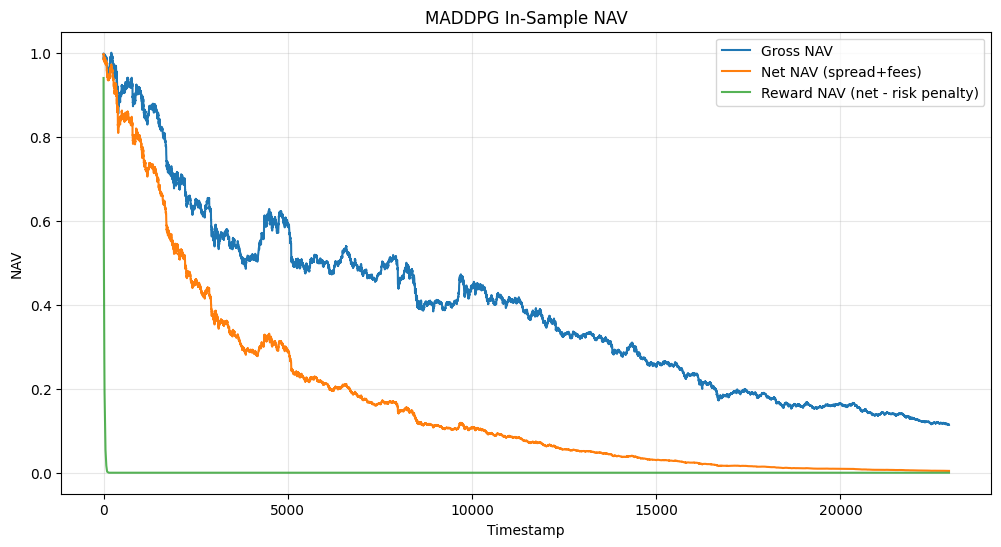

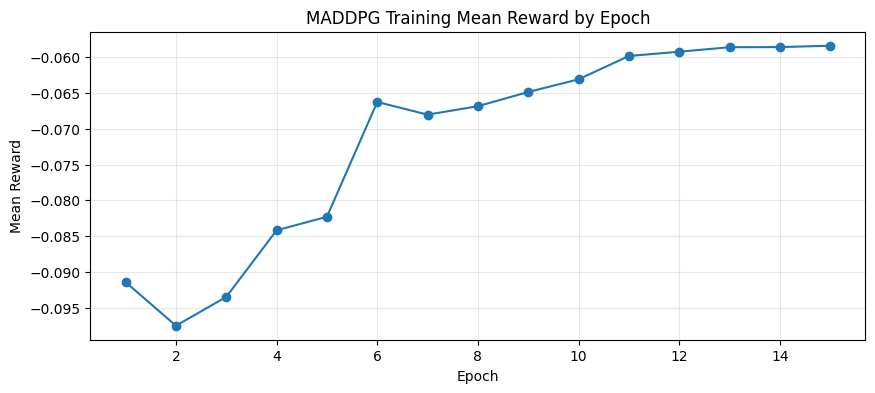

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =========================================================
# Build in-sample portfolio curve from df_pred
# gross: 只看持仓收益
# net  : 扣掉 spread + buy fee + sell fee
# =========================================================
def build_insample_nav_from_pred(df_pred: pd.DataFrame, cfg: CFG):
    need_cols = [
        cfg.day_col,
        cfg.time_col,
        "gross_return_ts",
        "spread_cost_ts",
        "buy_fee_ts",
        "sell_fee_ts",
        "risk_penalty_ts",
        "turnover_ts",
    ]
    x = df_pred[need_cols].copy()

    # 每个 timestamp 这些列在同一时点下对所有股票都一样（因为是组合层面的值被写回到每一行）
    # 所以 groupby 后取 first 即可
    ts_curve = (
        x.sort_values([cfg.day_col, cfg.time_col])
         .groupby([cfg.day_col, cfg.time_col], as_index=False)
         .first()
         .copy()
    )

    ts_curve["net_return_ts"] = (
        ts_curve["gross_return_ts"].fillna(0.0)
        - ts_curve["spread_cost_ts"].fillna(0.0)
        - ts_curve["buy_fee_ts"].fillna(0.0)
        - ts_curve["sell_fee_ts"].fillna(0.0)
    )

    # 如果你想把 risk penalty 也作为“策略效用净值”画出来，可以再加一条
    ts_curve["reward_return_ts"] = (
        ts_curve["gross_return_ts"].fillna(0.0)
        - ts_curve["spread_cost_ts"].fillna(0.0)
        - ts_curve["buy_fee_ts"].fillna(0.0)
        - ts_curve["sell_fee_ts"].fillna(0.0)
        - ts_curve["risk_penalty_ts"].fillna(0.0)
    )

    ts_curve["gross_nav"] = (1.0 + ts_curve["gross_return_ts"].fillna(0.0)).cumprod()
    ts_curve["net_nav"] = (1.0 + ts_curve["net_return_ts"].fillna(0.0)).cumprod()
    ts_curve["reward_nav"] = (1.0 + ts_curve["reward_return_ts"].fillna(0.0)).cumprod()

    return ts_curve


# =========================================================
# Build curve
# =========================================================
insample_curve = build_insample_nav_from_pred(df_pred, cfg)

print(insample_curve.head())
print(insample_curve.tail())


# =========================================================
# Plot in-sample NAV
# =========================================================
plt.figure(figsize=(12, 6))
plt.plot(insample_curve["gross_nav"], label="Gross NAV")
plt.plot(insample_curve["net_nav"], label="Net NAV (spread+fees)")
plt.plot(insample_curve["reward_nav"], label="Reward NAV (net - risk penalty)", alpha=0.8)
plt.title("MADDPG In-Sample NAV")
plt.xlabel("Timestamp")
plt.ylabel("NAV")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# =========================================================
# Optional: plot training reward history
# =========================================================
plt.figure(figsize=(10, 4))
plt.plot(hist_df["epoch"] + 1, hist_df["mean_reward"], marker="o")
plt.title("MADDPG Training Mean Reward by Epoch")
plt.xlabel("Epoch")
plt.ylabel("Mean Reward")
plt.grid(True, alpha=0.3)
plt.show()

Step 1/2: prepare_dataframe ...


Prepare dataframe:   0%|          | 0/6 [00:00<?, ?it/s]

Build snapshots:   0%|          | 0/8063 [00:00<?, ?it/s]

Done prepare_dataframe. rows=402,758, timestamps=8,063
Step 2/2: build_snapshot_cache ...


Cache snapshots:   0%|          | 0/8063 [00:00<?, ?it/s]

Done build_snapshot_cache. cached timestamps=8,063


Predict timestamps:   0%|          | 0/8063 [00:00<?, ?it/s]

Backtest timestamps with cost:   0%|          | 0/8063 [00:00<?, ?it/s]

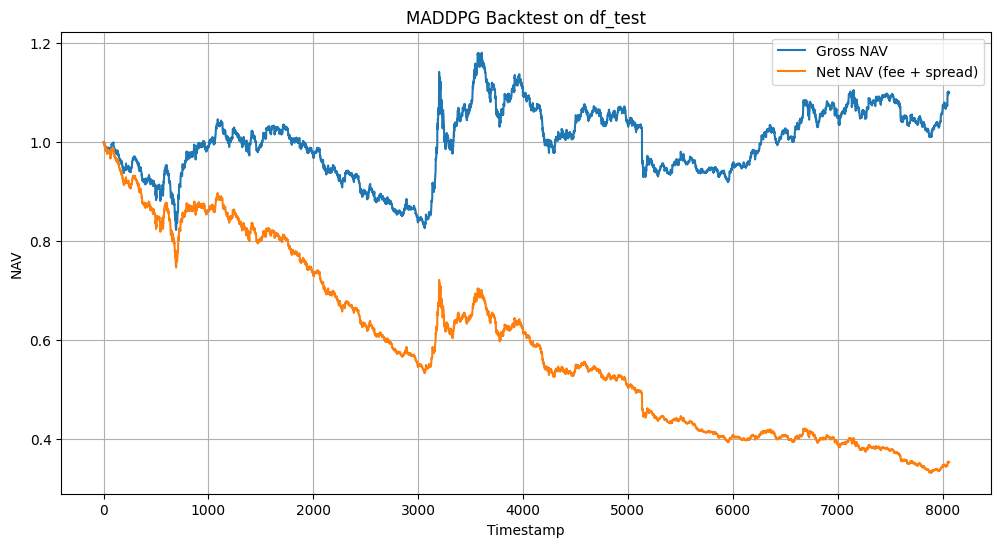

   SecuCode  TradingDay  TimeEnd  target_weight  final_weight  sellable_weight
0       400    20231205      945       0.000000      0.000000              0.0
1       415    20231205      945       0.000000      0.000000              0.0
2       423    20231205      945       0.000000      0.000000              0.0
3       425    20231205      945       0.020942      0.020942              0.0
4       503    20231205      945       0.000000      0.000000              0.0
   TradingDay  TimeEnd  gross_return  spread_cost   buy_fee  sell_fee  \
0    20231205      945     -0.000956     0.000421  0.000364       0.0   
1    20231205     1000     -0.000401     0.000000  0.000000       0.0   
2    20231205     1015      0.000767     0.000000  0.000000       0.0   
3    20231205     1030     -0.001180     0.000000  0.000000       0.0   
4    20231205     1045     -0.002314     0.000000  0.000000       0.0   

   total_fee  net_return  turnover  nav_gross   nav_net  
0   0.000364   -0.001741     

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# =========================================================
# Predict on df_test
# =========================================================
df_pred_test = predict_maddpg_weights(df_test, loaded_model, cfg)
df_pred_test.to_parquet("df_test_maddpg_pred.parquet", index=False)


# =========================================================
# Backtest with fee + spread using executed weight
# =========================================================
def backtest_from_weight_frame_with_cost(
    df_weight: pd.DataFrame,
    cfg: CFG,
    weight_col: str = "final_weight",
):
    """
    Use already executed weights (recommended: final_weight),
    and compute:
      gross_return
      spread_cost
      buy_fee
      sell_fee
      net_return
      nav_gross
      nav_net
      turnover
    """
    need_cols = [
        cfg.day_col, cfg.time_col, cfg.stock_col,
        weight_col, cfg.ret_col, cfg.price_col, cfg.spread_col
    ]
    x = (
        df_weight[need_cols]
        .copy()
        .sort_values([cfg.day_col, cfg.time_col, cfg.stock_col])
        .reset_index(drop=True)
    )

    records = []
    prev_w_map = {}

    for (d, t), sub in tqdm(
        x.groupby([cfg.day_col, cfg.time_col], sort=True),
        desc="Backtest timestamps with cost"
    ):
        codes = sub[cfg.stock_col].values
        w = sub[weight_col].values.astype(np.float32)
        ret_next = sub[cfg.ret_col].values.astype(np.float32)
        mid = sub[cfg.price_col].values.astype(np.float32)
        spread = sub[cfg.spread_col].values.astype(np.float32)

        prev_w = np.fromiter(
            (prev_w_map.get(code, 0.0) for code in codes),
            dtype=np.float32,
            count=len(codes)
        )

        delta_w = w - prev_w
        buy_w = np.maximum(delta_w, 0.0).astype(np.float32)
        sell_w = np.maximum(-delta_w, 0.0).astype(np.float32)

        spread_frac = np.divide(
            spread,
            np.maximum(mid, 1e-8),
            out=np.zeros_like(spread, dtype=np.float32),
            where=np.maximum(mid, 1e-8) > 0
        ).astype(np.float32)

        half_mult = 0.5 if cfg.use_half_spread else 1.0
        spread_cost_each = (buy_w + sell_w) * half_mult * spread_frac

        buy_fee_rate = cfg.broker_commission_rate + cfg.exchange_reg_transfer_rate
        sell_fee_rate = cfg.broker_commission_rate + cfg.exchange_reg_transfer_rate + cfg.sell_stamp_duty_rate

        buy_fee_each = buy_w * buy_fee_rate
        sell_fee_each = sell_w * sell_fee_rate

        gross_return = float(np.dot(w, ret_next))
        spread_cost = float(spread_cost_each.sum())
        buy_fee = float(buy_fee_each.sum())
        sell_fee = float(sell_fee_each.sum())
        total_fee = buy_fee + sell_fee
        net_return = gross_return - spread_cost - total_fee
        turnover = float(np.abs(delta_w).sum())

        records.append({
            cfg.day_col: d,
            cfg.time_col: t,
            "gross_return": gross_return,
            "spread_cost": spread_cost,
            "buy_fee": buy_fee,
            "sell_fee": sell_fee,
            "total_fee": total_fee,
            "net_return": net_return,
            "turnover": turnover,
        })

        prev_w_map = {code: float(wi) for code, wi in zip(codes, w)}

    bt = pd.DataFrame(records)
    if len(bt):
        bt["nav_gross"] = (1.0 + bt["gross_return"].fillna(0.0)).cumprod()
        bt["nav_net"] = (1.0 + bt["net_return"].fillna(0.0)).cumprod()

    return bt


bt_test = backtest_from_weight_frame_with_cost(
    df_pred_test,
    cfg,
    weight_col="final_weight",
)


# =========================================================
# Plot NAV
# =========================================================
plt.figure(figsize=(12, 6))
plt.plot(bt_test["nav_gross"], label="Gross NAV")
plt.plot(bt_test["nav_net"], label="Net NAV (fee + spread)")
plt.title("MADDPG Backtest on df_test")
plt.xlabel("Timestamp")
plt.ylabel("NAV")
plt.legend()
plt.grid(True)
plt.show()


# =========================================================
# Print summary
# =========================================================
print(df_pred_test[[cfg.stock_col, cfg.day_col, cfg.time_col, "target_weight", "final_weight", "sellable_weight"]].head())
print(bt_test.head())

print("Final Gross NAV:", bt_test["nav_gross"].iloc[-1] if len(bt_test) else np.nan)
print("Final Net NAV  :", bt_test["nav_net"].iloc[-1] if len(bt_test) else np.nan)
print("Mean gross ret :", bt_test["gross_return"].mean() if len(bt_test) else np.nan)
print("Mean net ret   :", bt_test["net_return"].mean() if len(bt_test) else np.nan)
print("Mean turnover  :", bt_test["turnover"].mean() if len(bt_test) else np.nan)
print("Mean total fee :", bt_test["total_fee"].mean() if len(bt_test) else np.nan)